In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"C:\Users\niles\OneDrive\Documents\Desktop\kaggel\Smartphone_Usage_Productivity_Dataset_50000.csv")

In [3]:
df

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U49996,44,Male,Business Owner,Android,5.9,5.4,5,6.6,1,11,5,3.0
49996,U49997,42,Other,Business Owner,Android,2.9,7.4,9,6.3,2,20,4,6.2
49997,U49998,27,Female,Freelancer,iOS,1.4,2.5,4,6.7,9,39,4,5.1
49998,U49999,41,Female,Business Owner,iOS,8.9,3.0,6,5.5,2,51,0,9.2


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,50000.0,39.034960,12.414877,18.0,28.0,39.0,50.0,60.0
Daily_Phone_Hours,50000.0,6.509116,3.170903,1.0,3.8,6.5,9.2,12.0
Social_Media_Hours,50000.0,4.267250,2.164743,0.5,2.4,4.3,6.1,8.0
Work_Productivity_Score,50000.0,5.503760,2.874806,1.0,3.0,5.5,8.0,10.0
Sleep_Hours,50000.0,6.497744,1.449551,4.0,5.2,6.5,7.8,9.0
Stress_Level,50000.0,5.504500,2.871095,1.0,3.0,6.0,8.0,10.0
App_Usage_Count,50000.0,32.438980,16.121510,5.0,18.0,32.0,46.0,60.0
Caffeine_Intake_Cups,50000.0,3.004580,1.996657,0.0,1.0,3.0,5.0,6.0
Weekend_Screen_Time_Hours,50000.0,8.006844,3.461300,2.0,5.0,8.0,11.0,14.0


In [5]:
df.isnull().sum()

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

In [46]:
df['Age'].astype(int)

0        58
1        25
2        19
3        35
4        33
         ..
49995    44
49996    42
49997    27
49998    41
49999    46
Name: Age, Length: 50000, dtype: int64

In [50]:
df.head()

,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [51]:
df.tail()

,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
49995,44,Male,Business Owner,Android,5.9,5.4,5,6.6,1,11,5,3.0
49996,42,Other,Business Owner,Android,2.9,7.4,9,6.3,2,20,4,6.2
49997,27,Female,Freelancer,iOS,1.4,2.5,4,6.7,9,39,4,5.1
49998,41,Female,Business Owner,iOS,8.9,3.0,6,5.5,2,51,0,9.2
49999,46,Other,Freelancer,Android,8.8,2.8,3,5.4,1,54,5,6.9


In [52]:
print(df.dtypes)


categorical_cols = ['Gender', 'Occupation', 'Device_Type']
for col in categorical_cols:
    df[col] = df[col].astype('category')

Age                            int64
Gender                        object
Occupation                    object
Device_Type                   object
Daily_Phone_Hours            float64
Social_Media_Hours           float64
Work_Productivity_Score        int64
Sleep_Hours                  float64
Stress_Level                   int64
App_Usage_Count                int64
Caffeine_Intake_Cups           int64
Weekend_Screen_Time_Hours    float64
dtype: object


# outlier detections

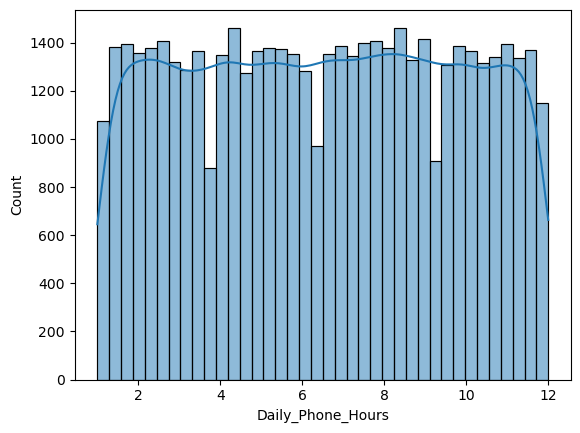

In [53]:
sns.histplot(df['Daily_Phone_Hours'], kde=True)
plt.show()


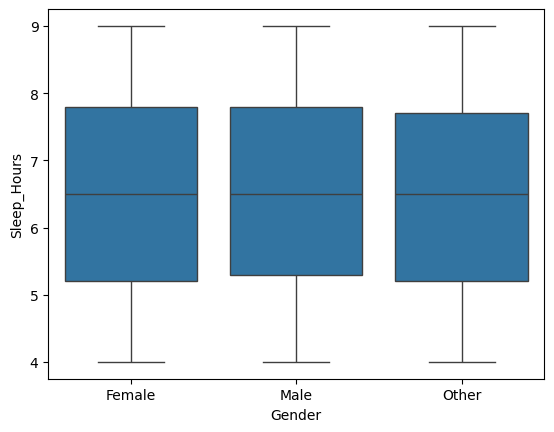

In [54]:
sns.boxplot(x='Gender', y='Sleep_Hours', data=df)
plt.show()


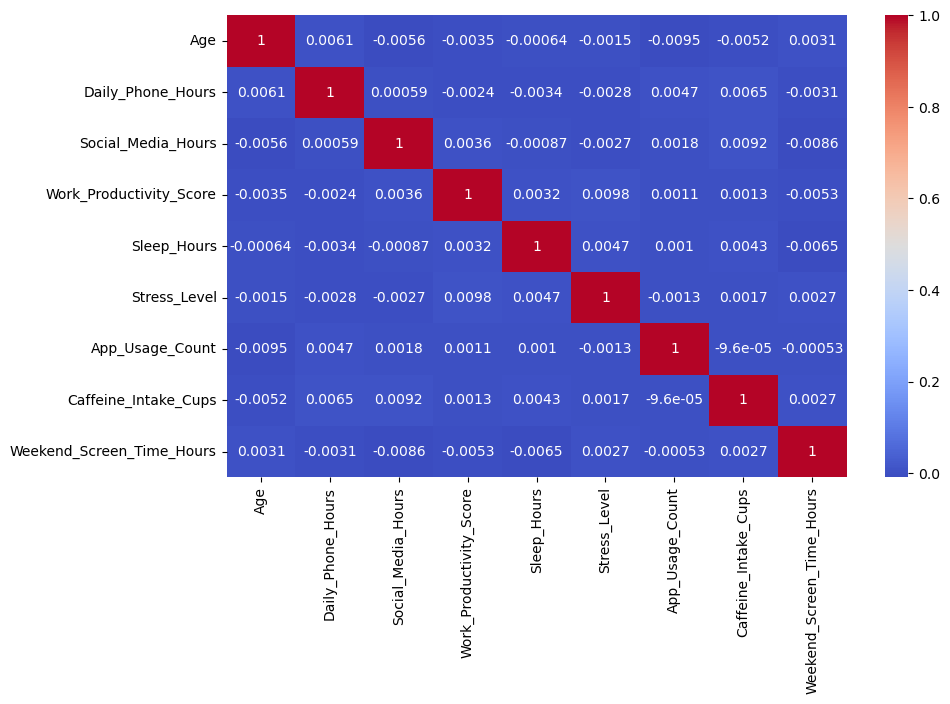

In [55]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


# bivariate analysis

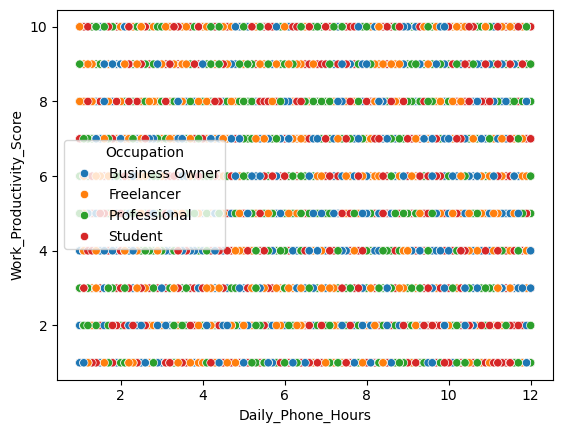

In [58]:
sns.scatterplot(x='Daily_Phone_Hours',
                y='Work_Productivity_Score', 
                hue='Occupation', data=df)
plt.show()


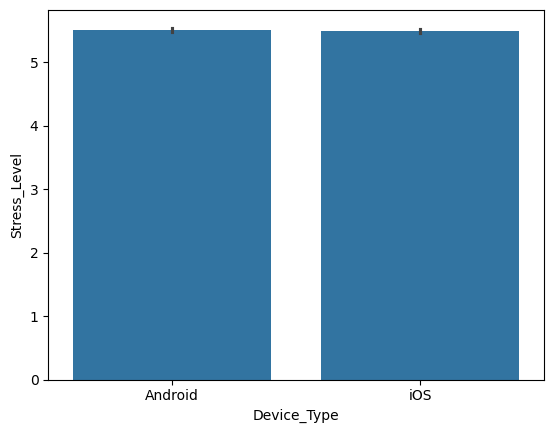

In [59]:
sns.barplot(x='Device_Type', y='Stress_Level', data=df)
plt.show()

# group comparision

In [61]:
print(df.groupby('Occupation')['Work_Productivity_Score'].mean())

Occupation
Business Owner    5.495064
Freelancer        5.511174
Professional      5.527516
Student           5.481106
Name: Work_Productivity_Score, dtype: float64


In [62]:

print(df.groupby('Device_Type')['Sleep_Hours'].mean())


Device_Type
Android    6.494709
iOS        6.500799
Name: Sleep_Hours, dtype: float64


# feature engineering

In [66]:
df['Social_Media_Ratio'] = df['Social_Media_Hours'] / df['Daily_Phone_Hours']
df['Sleep_Category'] = pd.cut(df['Sleep_Hours'], 
                              bins=[0,6,8,12], 
                              labels=['Low','Normal','High'])

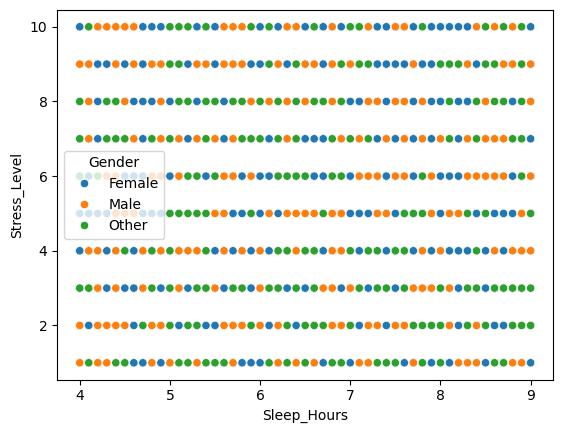

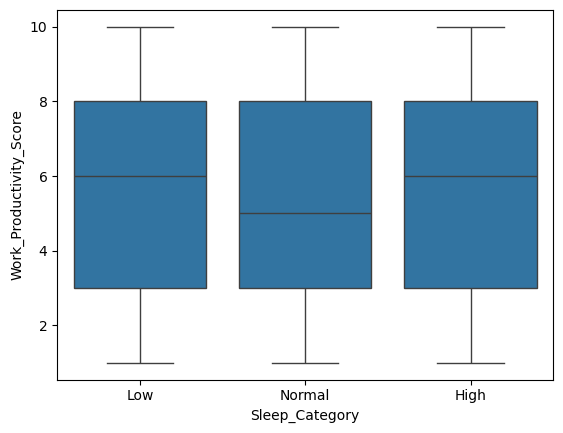

In [67]:
sns.scatterplot(x='Sleep_Hours', y='Stress_Level', hue='Gender', data=df)
plt.show()

sns.boxplot(x='Sleep_Category', y='Work_Productivity_Score', data=df)
plt.show()


# Compare Average Screen Time

In [68]:

print(df.groupby('Gender')['Daily_Phone_Hours'].mean())

print(df.groupby('Gender')['Weekend_Screen_Time_Hours'].mean())

Gender
Female    6.509989
Male      6.522696
Other     6.494583
Name: Daily_Phone_Hours, dtype: float64
Gender
Female    8.057402
Male      7.997325
Other     7.965659
Name: Weekend_Screen_Time_Hours, dtype: float64


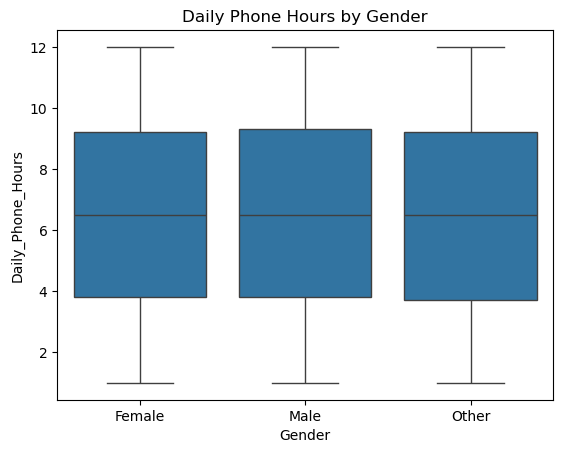

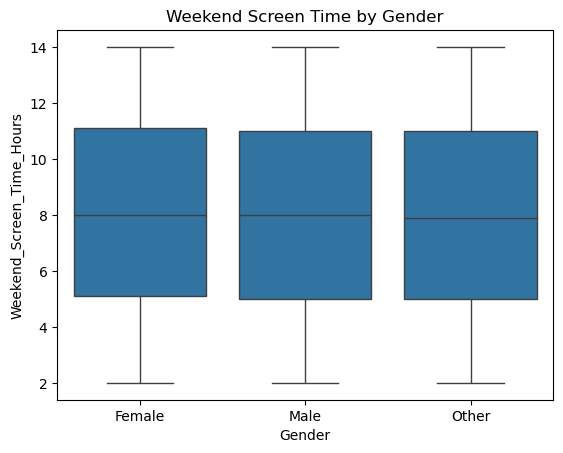

In [69]:
# Daily phone hours distribution by gender
sns.boxplot(x='Gender', y='Daily_Phone_Hours', data=df)
plt.title("Daily Phone Hours by Gender")
plt.show()

# Weekend screen time distribution by gender
sns.boxplot(x='Gender', y='Weekend_Screen_Time_Hours', data=df)
plt.title("Weekend Screen Time by Gender")
plt.show()

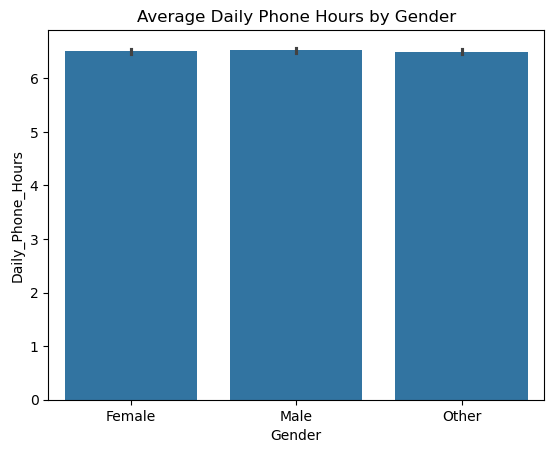

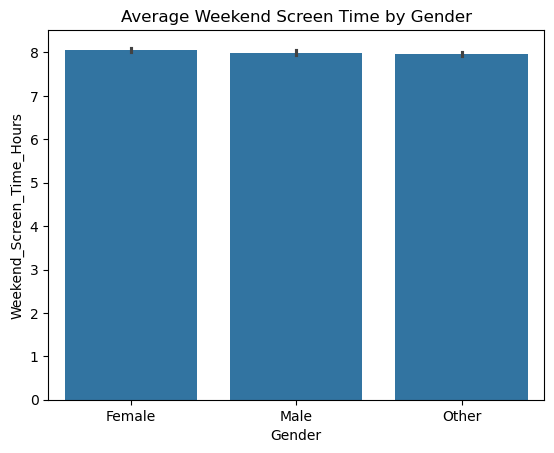

In [70]:
# Average daily phone hours by gender
sns.barplot(x='Gender', y='Daily_Phone_Hours', data=df, estimator='mean')
plt.title("Average Daily Phone Hours by Gender")
plt.show()

# Average weekend screen time by gender
sns.barplot(x='Gender', y='Weekend_Screen_Time_Hours', data=df, estimator='mean')
plt.title("Average Weekend Screen Time by Gender")
plt.show()

In [71]:
from scipy.stats import ttest_ind

male_daily = df[df['Gender'] == 'Male']['Daily_Phone_Hours']
female_daily = df[df['Gender'] == 'Female']['Daily_Phone_Hours']

t_stat, p_val = ttest_ind(male_daily, female_daily)
print("T-statistic:", t_stat, "P-value:", p_val)

T-statistic: 0.3668024070831243 P-value: 0.7137687367011737
